# Correlation analysis between Grin2a basal expression and single gene LogFC

In [2]:
# Import packages
import os
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from matplotlib.colors import ListedColormap
from natsort import natsorted

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Set IO path
base_path = '/home/jiahao/wanglab/Data/Analyzed/2024-12-02-Mingrui-SCZ/'
expr_path = os.path.join(base_path, 'expr')
fig_path = os.path.join(base_path, 'figures')
output_path = os.path.join(base_path, 'output')
os.makedirs(output_path, exist_ok=True)

sc.settings.figdir = fig_path
input_path = os.path.join(expr_path, 'DE analysis')

In [ ]:
# Load adata
adata = sc.read_h5ad(os.path.join(expr_path, '2025-07-03-finalized-ct-rgn.h5ad'))
adata

## Color palettes

In [5]:
# export as editable fonts
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

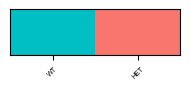

In [6]:
# WT, HET
condition_order = ['WT', 'HET']
condition_pl = sns.color_palette(['#00bfc4', '#f8766d'])
condition_cmap = ListedColormap(condition_pl.as_hex())
sns.palplot(condition_pl)
plt.xticks(range(len(condition_order)), condition_order, size=5, rotation=45)
plt.tight_layout()
# plt.savefig(os.path.join(fig_path, 'level_1_palette.pdf'))
plt.show()

## Load DEGs

In [7]:
# Load all sheets from the Excel file into a dictionary
l3_deg_combined_file_path = os.path.join(input_path, '2025-04-09_level_3_combined_DEG.xlsx')
excel_data = pd.ExcelFile(l3_deg_combined_file_path)

# Create a dictionary where keys are sheet names and values are DataFrames
l3_deg_combined_dict = {sheet_name: excel_data.parse(sheet_name) for sheet_name in excel_data.sheet_names}

## Load NMF modules

In [8]:
# Reorder gene module based on level 2 cell type expr
module_name_dict = {
    '1': 'M25', # 
    '2': 'M1', #
    '3': 'M24', # 
    '4': 'M26', # 
    '5': 'M13', # 
    '6': 'M27', # 
    '7': 'M28', # 
    '8': 'M29', # 
    '9': 'M14', # 
    '10': 'M30', # 
    '11': 'M12', # 
    '12': 'M10', # 
    '13': 'M7', # 
    '14': 'M4', # 
    '15': 'M9', # 
    '16': 'M31', # 
    '17': 'M32', # 
    '18': 'M20', # 
    '19': 'M6', # 
    '20': 'M33', # 
    '21': 'M15', # 
    '22': 'M2', #
    '23': 'M8', # 
    '24': 'M3', # 
    '25': 'M17', # 
    '26': 'M22', # 
    '27': 'M16', # 
    '28': 'M21', #
    '29': 'M11', #
    '30': 'M19', #
    '31': 'M23', #
    '32': 'M34', #
    '33': 'M18', #
    '34': 'M35', #
    '35': 'M5', #
}

In [9]:
# load cNMF top genes 
run_name = 'All_run'
n_genes = 50
current_output_path = os.path.join(output_path, "nmf", run_name)

top_genes = pd.read_csv(os.path.join(current_output_path, f'{run_name}_topgenes.csv'), index_col=0)
top_genes.columns = top_genes.columns.astype(str)
top_genes.columns = [module_name_dict[c] for c in top_genes.columns]
top_genes = top_genes.loc[:, natsorted(top_genes.columns)]
top_genes_dict = top_genes.head(n_genes).to_dict(orient='list')

In [10]:
# Select modules of interest
selected_modules = ['M28', 'M29', 'M27', 'M33', 'M7', 'M2', 'M4', 'M6', 'M26', 'M35']
selected_modules_genes = []
for module in selected_modules:
    selected_modules_genes.extend(top_genes_dict[module])

# Get unique genes
selected_modules_genes = list(set(selected_modules_genes))
len(selected_modules_genes)


430

## Basal Grin2a 

In [221]:
# Load basal Grin2a data
current_protocol = 'RIBO'
basal_grin2a_dict = pd.read_excel(os.path.join(input_path, '2025-04-17_basal_Grin2a.xlsx'), sheet_name=None)
grin2a_df = basal_grin2a_dict[current_protocol]
grin2a_df['level_3_label'] = grin2a_df['cell_type'].str.split('-').str[0]
grin2a_df['level_3_label'] = grin2a_df['level_3_label'].str.replace('/', '_')
grin2a_df['level_3_label'] = grin2a_df['level_3_label'].astype('category')
grin2a_df['level_3_label'].unique()
grin2a_df = grin2a_df.loc[:, ['level_3_label', 'Grin2a_expression']]
grin2a_df

,level_3_label,Grin2a_expression
0,TEGLU_L2_3,1.162185
1,TEGLU_L4_5,0.971603
2,TEGLU_L5_6,0.842755
3,TEGLU_L6,0.850652
4,TEGLU_CA,1.672495
5,TEGLU_Mix,0.301487
6,DGGRC,0.843257
7,TEINH_1,0.597353
8,TEINH_2,0.642172
9,TEINH_3,0.838104


In [222]:
# Select cell types of interest
ctype_list = ['TEGLU_L2_3', 'TEGLU_L4_5', 'TEGLU_L5_6', 'TEGLU_L6', 'TEGLU_CA', 'DGGRC', 'HABCHO', 
              'MSN_1', 'MSN_2', 'DEGLU', 'PEP', 'TEINH_1', 'TEINH_2', 'TEINH_3', 'TEINH_4']
logfc_df = grin2a_df.loc[grin2a_df['level_3_label'].isin(ctype_list), :].copy()
logfc_df

,level_3_label,Grin2a_expression
0,TEGLU_L2_3,1.162185
1,TEGLU_L4_5,0.971603
2,TEGLU_L5_6,0.842755
3,TEGLU_L6,0.850652
4,TEGLU_CA,1.672495
6,DGGRC,0.843257
7,TEINH_1,0.597353
8,TEINH_2,0.642172
9,TEINH_3,0.838104
10,TEINH_4,0.418524


In [223]:
# Calculate logFC
current_protocol = 'STAR'
for current_gene in adata.var_names:
    lfc_per_cell_type = {}
    for cell_type in logfc_df['level_3_label'].tolist():
        key = f"{cell_type}_{current_protocol}"

        df = l3_deg_combined_dict.get(key)
        if df is None or current_gene not in df['names'].values:
            continue

        lfc = df.loc[df['names'] == current_gene, 'logfoldchanges']
        lfc_per_cell_type[cell_type] = lfc.values[0]
    lfc_df = pd.DataFrame(list(lfc_per_cell_type.items()), columns=['level_3_label', current_gene])
    logfc_df = pd.merge(logfc_df, lfc_df, on='level_3_label', how='inner')

In [224]:
# Create cell type by gene logFC matrix
logfc_df.index = logfc_df['level_3_label']
logfc_df = logfc_df.drop(columns=['level_3_label'])
logfc_df = logfc_df.sort_values(by='Grin2a_expression', ascending=True)
logfc_df

,Grin2a_expression,A2m,A4galt,Aacs,Aak1,Abca5,Abcb1a,Abcb9,Abcc9,Abcf3,...,Zmiz1,Zmym1,Zmym3,Zmynd10,Znfx1,Znrf1,Zswim6,Zswim8,Zxdb,Zyg11b
level_3_label,,,,,,,,,,,,,,,,,,,,,
PEP,0.351916,-0.181720,-0.398182,-0.126461,-0.333931,-0.071835,-0.073675,-0.396823,-1.036086,-0.087419,...,-0.285024,0.066245,-0.031945,0.293368,0.100094,-0.019854,0.209061,-1.024269,-0.073178,-0.139998
TEINH_4,0.418524,0.170016,-0.144188,0.258856,-0.007752,-0.296180,0.057414,-0.299688,-0.872666,-0.018060,...,-0.434690,0.202697,-0.044471,0.510894,0.117975,-0.213940,-0.497517,0.215290,-0.116227,0.175451
HABCHO,0.430511,-0.970147,-0.596399,0.585101,-0.159280,-0.424479,-0.160554,-0.134902,-0.935292,-0.406268,...,-0.079582,-0.255511,-0.351513,-0.265069,-0.288292,0.119788,-0.266363,-0.935217,-0.052684,-0.199434
MSN_2,0.532247,-0.826665,-0.495576,0.357189,-0.169051,-0.070270,-0.106261,-0.089383,-0.724876,-0.120723,...,-0.314437,0.213797,0.109016,-0.596648,-0.334182,-0.179426,0.113080,-0.478166,-0.047826,-0.235950
DEGLU,0.591046,0.010399,-0.557042,0.176174,-0.170925,-0.046516,-0.249092,-0.078056,-0.193035,-0.018029,...,-0.059656,-0.067993,0.048183,-0.250947,-0.449721,-0.291136,0.128378,-0.255774,0.041318,-0.154453
TEINH_1,0.597353,-0.371902,-0.040630,0.018653,-0.123542,0.092504,0.067032,-0.156707,-0.022410,0.074516,...,0.163269,-0.007688,-0.008083,0.009984,-0.673377,-0.052288,-0.016833,-0.244209,-0.063510,0.044740
TEINH_2,0.642172,0.851958,-0.498706,0.404492,0.101153,-0.036637,0.142034,-0.323997,-0.454756,-0.177670,...,-0.246179,0.648369,-0.099197,-0.656893,0.231810,-0.423187,0.260597,0.390079,0.258742,0.065982
MSN_1,0.680843,-0.350532,-0.546296,-0.028456,-0.142996,0.176794,-0.249330,-0.451119,-0.784850,-0.151381,...,-0.110408,-0.390532,0.031944,-0.388057,-0.357987,0.081597,0.233187,-0.255188,-0.015583,-0.215941
TEINH_3,0.838104,-0.637505,-0.239777,0.031600,-0.084061,-0.499816,-0.364692,0.634208,1.287470,-0.012142,...,-0.137184,0.163353,0.400139,-0.327877,0.078928,-0.240885,0.051666,-0.435038,0.384414,0.198735


In [225]:
# Calculate Spearman correlation coefficient
from scipy.stats import linregress, spearmanr

value_dict = {}
for current_gene in adata.var_names:

    # Grin2a_expression
    rho, pval = spearmanr(logfc_df['Grin2a_expression'], logfc_df[current_gene])
    slope, intercept, *_ = linregress(logfc_df['Grin2a_expression'], logfc_df[current_gene])
    value_dict[current_gene] = (rho, pval, slope, intercept)

coor_df = pd.DataFrame(value_dict).T
coor_df.columns = ['rho', 'pval', 'slope', 'intercept']

expr_mean_data = adata[(adata.obs['level_3_label'].isin(ctype_list)) & (adata.obs['protocol'] == current_protocol) & (adata.obs['condition'] == 'WT'), coor_df.index]
expr_mean = pd.DataFrame(expr_mean_data.layers['log2_norm1e4'].toarray().copy(), index=expr_mean_data.obs_names, columns=expr_mean_data.var_names)
expr_mean['level_3_label'] = expr_mean_data.obs['level_3_label']
expr_mean = expr_mean.groupby('level_3_label').mean()
coor_df['expr_mean'] = expr_mean.min(axis=0)
coor_df['sig'] = coor_df['pval'] < 0.05
coor_df

,rho,pval,slope,intercept,expr_mean,sig
A2m,-0.121429,0.666401,-0.216981,-0.118633,0.041489,False
A4galt,0.182143,0.515882,0.080718,-0.417439,0.153926,False
Aacs,-0.214286,0.443141,-0.213274,0.340812,0.061581,False
Aak1,0.175000,0.532748,0.018143,-0.108337,0.545120,False
Abca5,0.125000,0.657136,-0.146905,0.005972,0.126201,False
...,...,...,...,...,...,...
Znrf1,0.035714,0.899447,0.038298,-0.141821,0.276570,False
Zswim6,0.071429,0.800296,0.044395,0.021965,0.243964,False
Zswim8,0.475000,0.073571,0.656461,-0.691706,0.044231,False
Zxdb,0.278571,0.314709,0.049191,0.005364,0.737312,False


In [ ]:
coor_df.loc['Arc', :]

rho         -0.517857
pval         0.048004
slope       -0.441239
intercept   -0.550035
expr_mean    1.004747
sig              True
Name: Arc, dtype: object

In [220]:
coor_df.to_csv(os.path.join(output_path, 'grin2a_basal_coor_star_ribo.csv'))

### Scatter overview

In [197]:
overview_df = coor_df.copy()
overview_df['in_module'] = overview_df.index.isin(selected_modules_genes)
overview_df['-log10(pval)'] = -np.log10(overview_df['pval'])
overview_df

,rho,pval,slope,intercept,expr_mean,sig,in_module,-log10(pval)
A2m,0.228571,0.412566,0.216084,-0.767639,0.047165,False,False,0.384506
A4galt,-0.207143,0.458843,-0.028717,-0.235952,0.046414,False,False,0.338336
Aacs,0.610714,0.015593,0.342329,-0.035289,0.169071,True,False,1.807075
Aak1,0.450000,0.092357,0.166326,-0.345377,0.682760,False,False,1.034528
Abca5,-0.239286,0.390379,-0.305327,-0.014891,0.091977,False,False,0.408513
...,...,...,...,...,...,...,...,...
Znrf1,-0.017857,0.949635,0.041978,-0.187829,0.168696,False,False,0.022443
Zswim6,-0.096429,0.732453,-0.266947,0.249830,0.069354,False,False,0.135220
Zswim8,-0.378571,0.164091,-0.115761,0.044716,0.403368,False,False,0.784916
Zxdb,-0.214286,0.443141,0.016159,-0.133241,0.258594,False,False,0.353458


In [ ]:
# Label genes passing the threshold
expr_thresold = overview_df['expr_mean'].quantile(0.75)
overview_df['label'] = (overview_df['rho'] < 0) & (overview_df['expr_mean'] > expr_thresold) & (overview_df['sig'])
overview_df['label'].value_counts()

label
False    3427
True       20
Name: count, dtype: int64

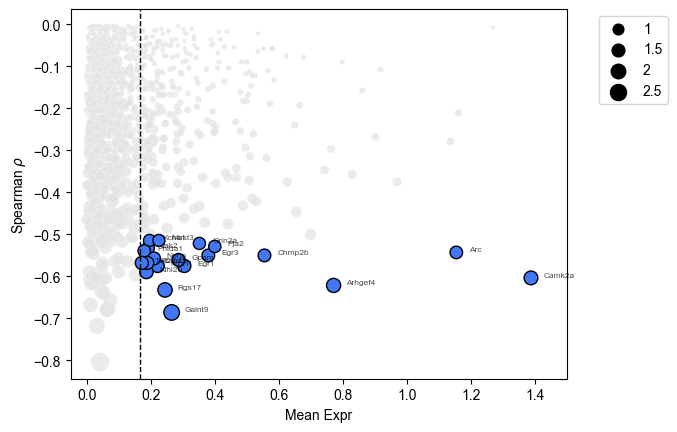

In [ ]:
# Plot scatter overview
size_norm = (overview_df['-log10(pval)'].min(), overview_df['-log10(pval)'].max())
sns.scatterplot(data=overview_df.loc[overview_df['rho'] < 0, :], 
            x='expr_mean', y='rho', hue='label', palette={False: '#e3e3e3', True: '#4178fa'}, 
            size='-log10(pval)', sizes=(10, 200), alpha=0.7, size_norm=size_norm, legend=False)

sns.scatterplot(data=overview_df.loc[(overview_df['rho'] < 0) & (overview_df['label']), :], 
            x='expr_mean', y='rho', color='#4178fa',
            size='-log10(pval)', sizes=(10, 200), alpha=1, 
            linewidth=1, edgecolor='k', size_norm=size_norm)

# Add text labels for each dot
for idx, row in overview_df.loc[overview_df['label'], :].iterrows():
    plt.text(row['expr_mean']+0.04, row['rho'], idx, fontsize=6, alpha=0.7, ha='left', va='bottom')

plt.axvline(x=expr_thresold, color='k', linestyle='--', linewidth=1)

# Customize legend to show specific size values
handles, labels = plt.gca().get_legend_handles_labels()
# Filter to get size legend entries and customize
size_values = [1, 1.5, 2, 2.5]
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l in ['False', 'True']:
        new_handles.append(h)
        new_labels.append(l)
    elif l == '-log10(pval)':
        new_handles.append(h)
        new_labels.append(l)
        
# Add custom size legend entries
for size_val in size_values:
    new_handles.append(plt.scatter([], [], s=(size_val - size_norm[0]) / (size_norm[1] - size_norm[0]) * (200 - 10) + 10, 
                                   color='k', alpha=1))
    new_labels.append(str(size_val))

plt.legend(new_handles, new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Mean Expr')
plt.ylabel(r'Spearman $\rho$')
plt.xlim(-0.05, 1.5)
plt.savefig(os.path.join(fig_path, 'grin2a_basal_overview.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [122]:
for i in overview_df.loc[overview_df['label']].index:
    print(i)

Arc
Arhgef4
Camk2a
Chmp2b
Egr1
Egr3
Frrs1l
Galnt9
Gpam
Grin2a
Jak2
Kcna1
Klhl20
Mast3
Nono
Phlda1
Pja2
Rbm4b
Rgs17
Tsc22d3


### Scatter plot for single gene

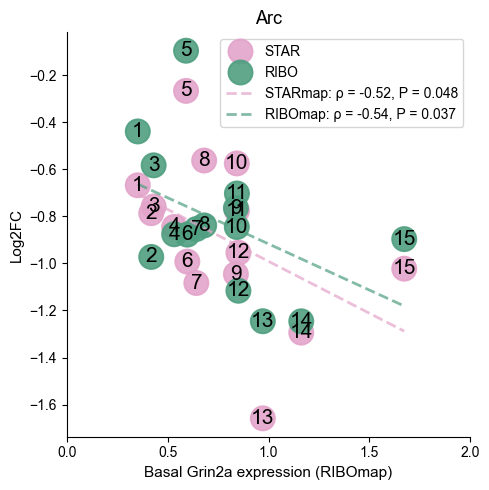

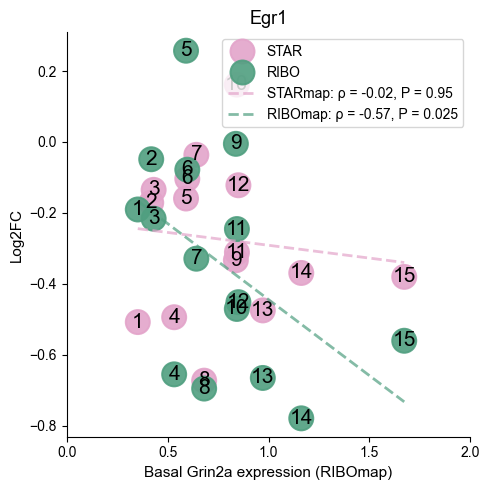

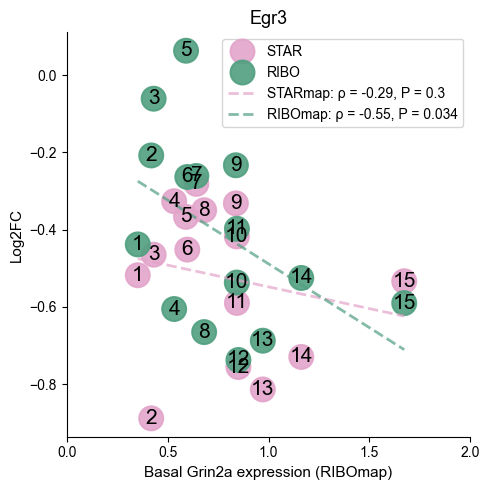

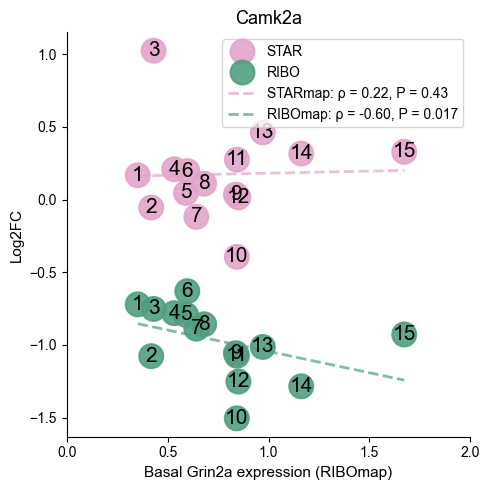

In [ ]:
# Plot scatter for each gene
# for gene_of_interest in genes_to_label:
for gene_of_interest in ['Arc', 'Egr1', 'Egr3', 'Camk2a']:
    protocols = ['STAR', 'RIBO']
    metric_of_interest = 'logfoldchanges'  # or whatever metric you're using
    current_df = grin2a_df.loc[grin2a_df['level_3_label'].isin(ctype_list), :].copy()
    merged_all = []

    # Loop over protocols and collect data
    for protocol in protocols:
        lfc_per_cell_type = {}

        for cell_type in current_df['level_3_label'].tolist():
            prefix = cell_type.replace("/", "_").split("-")[0]
            key = f"{prefix}_{protocol}"

            df = l3_deg_combined_dict.get(key)
            if df is None or gene_of_interest not in df['names'].values:
                continue

            lfc = df.loc[df['names'] == gene_of_interest, metric_of_interest]
            lfc_per_cell_type[cell_type] = lfc.values[0]

        # Construct DataFrame and merge
        lfc_df = pd.DataFrame(list(lfc_per_cell_type.items()), columns=['level_3_label', metric_of_interest])
        merged_df = pd.merge(current_df, lfc_df, on='level_3_label', how='inner')
        merged_df['level_3_label'] = merged_df['level_3_label'].str.split('-').str[0]
        merged_df = merged_df[merged_df['level_3_label'] != 'TEGLU_Mix']
        merged_df['protocol'] = protocol
        merged_df = merged_df.sort_values(by='Grin2a_expression', ascending=True)
        merged_df = merged_df.reset_index(drop=True)
        merged_df['rank'] = merged_df.index + 1
        merged_all.append(merged_df)

    # Combine STAR + RIBO
    merged_all_df = pd.concat(merged_all)

    # --- PLOT ---
    plt.figure(figsize=(5, 5))
    ax = sns.scatterplot(
        data=merged_all_df,
        x='Grin2a_expression',
        y=metric_of_interest,
        hue='protocol',
        palette={'STAR': '#e3a4ca', 'RIBO': '#509f80'},
        s=300,
        edgecolor=None,
        alpha=0.9
    )

    # Add regression lines per protocol
    for protocol, color in zip(['STAR', 'RIBO'], ['#e3a4ca', '#509f80']):
        subset = merged_all_df[merged_all_df['protocol'] == protocol]
        if subset.shape[0] < 3:
            continue

        rho, pval = spearmanr(subset['Grin2a_expression'], subset[metric_of_interest])
        slope, intercept, *_ = linregress(subset['Grin2a_expression'], subset[metric_of_interest])
        x_vals = [subset['Grin2a_expression'].min(), subset['Grin2a_expression'].max()]
        x_vals
        y_vals = [slope * x + intercept for x in x_vals]

        ax.plot(x_vals, y_vals, linestyle='--', color=color, linewidth=2,
                label=f"{protocol}map: ρ = {rho:.2f}, P = {pval:.2g}", alpha=0.7)

    # loop through each x,y pair
    for _, row in merged_all_df.iterrows():
        ax.annotate(row['rank'],  xy=(row['Grin2a_expression'], row[metric_of_interest],), 
                    color='k', 
                    fontsize=15, weight='medium',
                    horizontalalignment='center',
                    verticalalignment='center')
        
    # Formatting
    ax.set_title(f"{gene_of_interest}", fontsize=13)
    ax.set_xlabel("Basal Grin2a expression (RIBOmap)", fontsize=11)
    ax.set_ylabel("Log2FC", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 2)
    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])

    plt.legend(loc='upper right')
    plt.tight_layout()
    # plt.savefig(os.path.join(fig_path,f'{gene_of_interest}_basal_scatter.pdf'), format='pdf', dpi=300)
    plt.show()
